# 03 Advanced Spectral Modeling and Ensemble

近赤外スペクトルから含水率を推定するための高度化ノートブックです。

このノートでは、樹種名・樹種番号をモデル入力に使わず、スペクトルだけから含水率を推定する樹種非依存モデルを作ります。樹種情報は、必要時の診断メタデータとしてだけ扱います。

- `data/train.csv` / `data/test.csv` の読み込み
- スペクトル列、目的変数列、診断用メタデータ列の判定
- SNV / Savitzky-Golay / MSC の scikit-learn Transformer 化
- 通常KFoldによる PLS / Ridge / SVR 比較
- OOF予測とスコアの保存
- CV上位モデルの単純平均・重み付き平均アンサンブル
- test予測CSVの保存
- Stage B以降の木系モデル、波数範囲選択、VIP、Adversarial validation、Local PLS、stackingの追加枠

参考: nirpyresearch の PLS、scatter correction、band selection の考え方を参考にしつつ、このプロジェクトでは必ずPipeline内fitを優先します。樹種情報はモデル入力に使いません。


## 0. ライブラリと設定

`RUN_STAGE_A = True` のまま実行すると、主要前処理 x PLS/Ridge/SVR の比較から test 予測保存まで進みます。Stage B以降は計算が重くなるため、必要なセルのフラグを `True` に変更して実行します。


In [1]:
from __future__ import annotations

from pathlib import Path
from dataclasses import dataclass
import json
import math
import os
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import savgol_filter

from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin, clone
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
    RandomForestClassifier,
)
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF, WhiteKernel
from sklearn.linear_model import ElasticNet, LogisticRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score
from sklearn.model_selection import GroupKFold, KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.utils.validation import check_array, check_is_fitted

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

sns.set_theme(style="whitegrid", context="notebook")

def find_project_dir(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    fallback_candidates = [Path("/Users/ogawatomohiro/myproject")]
    for candidate in [start, *start.parents, *fallback_candidates]:
        if (candidate / "data" / "train.csv").exists() and (candidate / "data" / "test.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing data/train.csv and data/test.csv")


PROJECT_DIR = find_project_dir()
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
SAMPLE_SUBMIT_PATH = DATA_DIR / "sample_submit.csv"

ENCODING = "cp932"
RANDOM_STATE = 42
N_SPLITS_MAX = 5

RUN_STAGE_A = True
RUN_STAGE_B = True
RUN_INTERVAL_SELECTION = True
RUN_VIP_SELECTION = False
RUN_ADVERSARIAL_VALIDATION = False
RUN_LOCAL_MODEL = False
RUN_STACKING = False

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)


## 1. データ読み込みと列判定

既存ノートブックと同じく、`cp932` で読み込みます。ID列・目的変数列・診断用メタデータ列は候補名から判定し、残りの数値変換できる列をスペクトル列として扱います。樹種名・樹種番号はモデル入力には使いません。


In [2]:
def read_csv_with_fallback(path: Path, encodings=("cp932", "utf-8", "shift_jis")) -> pd.DataFrame:
    last_error = None
    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception as exc:
            last_error = exc
    raise RuntimeError(f"Could not read {path}: {last_error}")


def pick_first_existing(columns, candidates, required=True, label="column"):
    for c in candidates:
        if c in columns:
            return c
    if required:
        raise ValueError(f"Could not find {label}. candidates={candidates}")
    return None


def detect_spectral_columns(df: pd.DataFrame, exclude_cols: list[str]) -> list[str]:
    spectral_cols = []
    for col in df.columns:
        if col in exclude_cols:
            continue
        try:
            float(col)
        except Exception:
            continue
        spectral_cols.append(col)
    if not spectral_cols:
        raise ValueError("No spectral columns were detected. Check column names.")
    return spectral_cols


train = read_csv_with_fallback(TRAIN_PATH)
test = read_csv_with_fallback(TEST_PATH)
sample_submit = read_csv_with_fallback(SAMPLE_SUBMIT_PATH) if SAMPLE_SUBMIT_PATH.exists() else None

TARGET_COL = pick_first_existing(train.columns, ["含水率", "mc", "moisture", "moisture_content", "target"], label="target column")
SAMPLE_COL = pick_first_existing(train.columns, ["sample number", "sample_id", "id", "ID"], required=False, label="sample id column")
SPECIES_COL = pick_first_existing(train.columns, ["樹種", "species", "species_name"], required=False, label="species column")
SPECIES_NUM_COL = pick_first_existing(train.columns, ["species number", "species_id", "species_no"], required=False, label="species id column")

id_cols = [c for c in [SAMPLE_COL, SPECIES_NUM_COL, SPECIES_COL] if c is not None]
spectral_cols = detect_spectral_columns(train, exclude_cols=id_cols + [TARGET_COL])
wavenumbers = np.array([float(c) for c in spectral_cols], dtype=float)

X = train[spectral_cols].astype(float).copy()
y = train[TARGET_COL].astype(float).copy()
X_test = test[spectral_cols].astype(float).copy()

if SPECIES_COL is not None:
    diagnostic_group = train[SPECIES_COL].astype(str).copy()
elif SPECIES_NUM_COL is not None:
    diagnostic_group = train[SPECIES_NUM_COL].astype(str).copy()
else:
    diagnostic_group = pd.Series("unknown", index=train.index, name="diagnostic_group")

# 樹種情報はモデル入力・主評価のfold作成には使わない。必要時の診断メタデータとしてだけ保持する。
species = diagnostic_group.copy()
groups = diagnostic_group.copy()

metadata = {
    "train_shape": train.shape,
    "test_shape": test.shape,
    "target_col": TARGET_COL,
    "sample_col": SAMPLE_COL,
    "species_col": SPECIES_COL,
    "species_num_col": SPECIES_NUM_COL,
    "n_spectral_cols": len(spectral_cols),
    "wavenumber_min": float(wavenumbers.min()),
    "wavenumber_max": float(wavenumbers.max()),
    "wavenumber_order": "descending" if np.all(np.diff(wavenumbers) < 0) else "ascending" if np.all(np.diff(wavenumbers) > 0) else "mixed",
    "diagnostic_group_col": SPECIES_COL or SPECIES_NUM_COL,
    "n_diagnostic_groups": int(diagnostic_group.nunique()),
}

print(json.dumps(metadata, ensure_ascii=False, indent=2))
display(train[id_cols + [TARGET_COL]].head())


{
  "train_shape": [
    1322,
    1559
  ],
  "test_shape": [
    550,
    1558
  ],
  "target_col": "含水率",
  "sample_col": "sample number",
  "species_col": "樹種",
  "species_num_col": "species number",
  "n_spectral_cols": 1555,
  "wavenumber_min": 3999.82139,
  "wavenumber_max": 9993.76781,
  "wavenumber_order": "descending",
  "diagnostic_group_col": "樹種",
  "n_diagnostic_groups": 13
}


,sample number,species number,樹種,含水率
0,1,1,イチョウ,216.129032
1,2,1,イチョウ,210.752688
2,3,1,イチョウ,205.913979
3,4,1,イチョウ,201.075269
4,5,1,イチョウ,196.236559


## 2. 前処理Transformer

前処理は必ずPipelineに入れ、各foldのtrainだけでfitされるようにします。特にMSCはfit時に基準スペクトルを保存し、validation/testにはその基準を使ってtransformします。


In [3]:
class SNVTransformer(BaseEstimator, TransformerMixin):
    """Standard normal variate: row-wise centering and scaling."""

    def __init__(self, eps: float = 1e-12):
        self.eps = eps

    def fit(self, X, y=None):
        X = check_array(X, dtype=float)
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X):
        check_is_fitted(self, "n_features_in_")
        X = check_array(X, dtype=float)
        mean = X.mean(axis=1, keepdims=True)
        std = X.std(axis=1, keepdims=True)
        std = np.where(std < self.eps, self.eps, std)
        return (X - mean) / std


class SavitzkyGolayTransformer(BaseEstimator, TransformerMixin):
    """Savitzky-Golay smoothing or derivative along spectral axis."""

    def __init__(self, window_length: int = 21, polyorder: int = 2, deriv: int = 0, delta: float = 1.0, mode: str = "interp"):
        self.window_length = window_length
        self.polyorder = polyorder
        self.deriv = deriv
        self.delta = delta
        self.mode = mode

    def fit(self, X, y=None):
        X = check_array(X, dtype=float)
        self.n_features_in_ = X.shape[1]
        self.window_length_ = self._valid_window_length(self.window_length, self.n_features_in_)
        self.polyorder_ = min(int(self.polyorder), self.window_length_ - 1)
        return self

    @staticmethod
    def _valid_window_length(window_length, n_features):
        window = int(window_length)
        if window % 2 == 0:
            window += 1
        if window > n_features:
            window = n_features if n_features % 2 == 1 else n_features - 1
        window = max(window, 3)
        return window

    def transform(self, X):
        check_is_fitted(self, ["n_features_in_", "window_length_", "polyorder_"])
        X = check_array(X, dtype=float)
        return savgol_filter(
            X,
            window_length=self.window_length_,
            polyorder=self.polyorder_,
            deriv=int(self.deriv),
            delta=float(self.delta),
            axis=1,
            mode=self.mode,
        )


class MSCTransformer(BaseEstimator, TransformerMixin):
    """Multiplicative scatter correction using the train-fold mean spectrum."""

    def __init__(self, eps: float = 1e-12):
        self.eps = eps

    def fit(self, X, y=None):
        X = check_array(X, dtype=float)
        self.n_features_in_ = X.shape[1]
        self.reference_ = X.mean(axis=0)
        return self

    def transform(self, X):
        check_is_fitted(self, ["n_features_in_", "reference_"])
        X = check_array(X, dtype=float)
        corrected = np.empty_like(X, dtype=float)
        ref = self.reference_
        for i, row in enumerate(X):
            slope, intercept = np.polyfit(ref, row, deg=1)
            if abs(slope) < self.eps:
                slope = self.eps
            corrected[i, :] = (row - intercept) / slope
        return corrected


class AdaptivePLSRegression(BaseEstimator, RegressorMixin):
    """PLSRegression that clips n_components to the current fold dimensions."""

    def __init__(self, n_components: int = 10, scale: bool = True, max_iter: int = 500, tol: float = 1e-06):
        self.n_components = n_components
        self.scale = scale
        self.max_iter = max_iter
        self.tol = tol

    def fit(self, X, y):
        X = check_array(X, dtype=float)
        y = np.asarray(y, dtype=float)
        max_components = max(1, min(X.shape[0] - 1, X.shape[1], int(self.n_components)))
        self.n_components_ = max_components
        self.model_ = PLSRegression(n_components=max_components, scale=self.scale, max_iter=self.max_iter, tol=self.tol)
        self.model_.fit(X, y)
        return self

    def predict(self, X):
        check_is_fitted(self, "model_")
        return self.model_.predict(X).ravel()


## 3. KFold評価関数

主評価は通常KFoldです。樹種情報はモデル入力にもfold作成にも使わず、必要時の診断メタデータとしてOOFに残します。失敗したモデルがあっても探索全体が止まらないよう、fold単位で例外を記録します。


In [4]:
def rmse_score(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def make_sample_cv(n_splits_max=N_SPLITS_MAX, random_state=RANDOM_STATE):
    n_splits = min(int(n_splits_max), len(X))
    if n_splits < 2:
        raise ValueError("KFold requires at least 2 samples.")
    return KFold(n_splits=n_splits, shuffle=True, random_state=random_state)


def make_group_cv(groups, n_splits_max=N_SPLITS_MAX):
    """Optional stress-test CV. Do not use as the primary model-selection metric."""
    n_groups = pd.Series(groups).nunique()
    n_splits = min(int(n_splits_max), int(n_groups))
    if n_splits < 2:
        raise ValueError("GroupKFold requires at least 2 unique groups.")
    return GroupKFold(n_splits=n_splits)


def evaluate_model_cv(
    estimator,
    X,
    y,
    model_name: str,
    cv=None,
    groups=None,
    return_oof: bool = True,
    sample_id=None,
    diagnostic_group=None,
):
    X_df = pd.DataFrame(X).reset_index(drop=True)
    y_ser = pd.Series(y).reset_index(drop=True).astype(float)
    groups_ser = pd.Series(groups).reset_index(drop=True) if groups is not None else None
    sample_id_ser = pd.Series(sample_id if sample_id is not None else np.arange(len(y_ser)), name="sample_id").reset_index(drop=True)
    diagnostic_ser = pd.Series(diagnostic_group if diagnostic_group is not None else "unknown", name="diagnostic_group").reset_index(drop=True)

    if cv is None:
        cv = make_sample_cv()

    oof_pred = np.full(len(y_ser), np.nan, dtype=float)
    fold_id = np.full(len(y_ser), -1, dtype=int)
    fold_scores = []
    errors = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X_df, y_ser, groups_ser), start=1):
        est = clone(estimator)
        try:
            est.fit(X_df.iloc[train_idx], y_ser.iloc[train_idx])
            pred = np.asarray(est.predict(X_df.iloc[valid_idx])).ravel()
            oof_pred[valid_idx] = pred
            fold_id[valid_idx] = fold

            fold_scores.append({
                "model_name": model_name,
                "fold": fold,
                "n_train": int(len(train_idx)),
                "n_valid": int(len(valid_idx)),
                "diagnostic_groups": ", ".join(sorted(diagnostic_ser.iloc[valid_idx].astype(str).unique()[:8])),
                "rmse": rmse_score(y_ser.iloc[valid_idx], pred),
                "mae": float(mean_absolute_error(y_ser.iloc[valid_idx], pred)),
                "r2": float(r2_score(y_ser.iloc[valid_idx], pred)),
                "status": "ok",
                "error": "",
            })
        except Exception as exc:
            errors.append({"fold": fold, "error": repr(exc)})
            fold_scores.append({
                "model_name": model_name,
                "fold": fold,
                "n_train": int(len(train_idx)),
                "n_valid": int(len(valid_idx)),
                "diagnostic_groups": ", ".join(sorted(diagnostic_ser.iloc[valid_idx].astype(str).unique()[:8])),
                "rmse": np.nan,
                "mae": np.nan,
                "r2": np.nan,
                "status": "failed",
                "error": repr(exc),
            })

    valid_mask = np.isfinite(oof_pred)
    if valid_mask.any():
        rmse_mean = rmse_score(y_ser[valid_mask], oof_pred[valid_mask])
        mae_mean = float(mean_absolute_error(y_ser[valid_mask], oof_pred[valid_mask]))
        r2_mean = float(r2_score(y_ser[valid_mask], oof_pred[valid_mask]))
    else:
        rmse_mean, mae_mean, r2_mean = np.inf, np.inf, np.nan

    score = {
        "model_name": model_name,
        "rmse_mean": rmse_mean,
        "mae_mean": mae_mean,
        "r2_mean": r2_mean,
        "n_valid_predictions": int(valid_mask.sum()),
        "n_failed_folds": int(len(errors)),
        "errors": json.dumps(errors, ensure_ascii=False),
    }

    oof_df = pd.DataFrame({
        "sample_id": sample_id_ser,
        "y_true": y_ser,
        "diagnostic_group": diagnostic_ser,
        "species": diagnostic_ser,  # backward-compatible diagnostic alias; never used as a model feature
        "model_name": model_name,
        "oof_pred": oof_pred,
        "fold": fold_id,
    })

    return {
        "model_name": model_name,
        "rmse_mean": rmse_mean,
        "mae_mean": mae_mean,
        "r2_mean": r2_mean,
        "fold_scores": pd.DataFrame(fold_scores),
        "oof_pred": oof_pred if return_oof else None,
        "oof_df": oof_df if return_oof else None,
        "score": score,
    }


def evaluate_model_group_stress(estimator, X, y, groups, model_name, cv=None, return_oof=True, sample_id=None, species=None):
    """Optional stress-test wrapper. Prefer evaluate_model_cv for primary evaluation."""
    return evaluate_model_cv(
        estimator=estimator,
        X=X,
        y=y,
        model_name=model_name,
        cv=cv,
        groups=groups,
        return_oof=return_oof,
        sample_id=sample_id,
        diagnostic_group=species if species is not None else groups,
    )


def summarize_errors_by_diagnostic_group(oof_df: pd.DataFrame) -> pd.DataFrame:
    tmp = oof_df.dropna(subset=["oof_pred"]).copy()
    group_col = "diagnostic_group" if "diagnostic_group" in tmp.columns else "species"
    tmp["abs_error"] = (tmp["y_true"] - tmp["oof_pred"]).abs()
    tmp["sq_error"] = (tmp["y_true"] - tmp["oof_pred"]) ** 2
    return (
        tmp.groupby(["model_name", group_col])
        .agg(
            n=("y_true", "size"),
            rmse=("sq_error", lambda s: float(np.sqrt(np.mean(s)))),
            mae=("abs_error", "mean"),
            y_mean=("y_true", "mean"),
        )
        .reset_index()
        .rename(columns={group_col: "diagnostic_group"})
    )


def summarize_errors_by_target_range(oof_df: pd.DataFrame, bins=4) -> pd.DataFrame:
    tmp = oof_df.dropna(subset=["oof_pred"]).copy()
    tmp["target_range"] = pd.qcut(tmp["y_true"], q=bins, duplicates="drop")
    tmp["abs_error"] = (tmp["y_true"] - tmp["oof_pred"]).abs()
    tmp["sq_error"] = (tmp["y_true"] - tmp["oof_pred"]) ** 2
    return (
        tmp.groupby(["model_name", "target_range"], observed=True)
        .agg(
            n=("y_true", "size"),
            rmse=("sq_error", lambda s: float(np.sqrt(np.mean(s)))),
            mae=("abs_error", "mean"),
        )
        .reset_index()
    )


## 4. 前処理候補と基本モデル候補

Stage Aでは、全前処理候補に対して PLS / Ridge / SVR を比較します。PLSの成分数はfold内のサンプル数・特徴量数に合わせて自動でクリップします。


In [5]:
def named_steps_for_preprocessing(name: str):
    candidates = {
        "original": [],
        "savgol_smooth_21": [("savgol", SavitzkyGolayTransformer(window_length=21, polyorder=2, deriv=0))],
        "savgol_1st_21": [("savgol", SavitzkyGolayTransformer(window_length=21, polyorder=2, deriv=1))],
        "savgol_2nd_21": [("savgol", SavitzkyGolayTransformer(window_length=21, polyorder=2, deriv=2))],
        "savgol_2nd_41": [("savgol", SavitzkyGolayTransformer(window_length=41, polyorder=2, deriv=2))],
        "snv": [("snv", SNVTransformer())],
        "snv_savgol_1st_21": [("snv", SNVTransformer()), ("savgol", SavitzkyGolayTransformer(window_length=21, polyorder=2, deriv=1))],
        "snv_savgol_2nd_21": [("snv", SNVTransformer()), ("savgol", SavitzkyGolayTransformer(window_length=21, polyorder=2, deriv=2))],
        "msc": [("msc", MSCTransformer())],
        "msc_savgol_2nd_21": [("msc", MSCTransformer()), ("savgol", SavitzkyGolayTransformer(window_length=21, polyorder=2, deriv=2))],
    }
    return candidates[name]


preprocessing_names = [
    "original",
    "savgol_smooth_21",
    "savgol_1st_21",
    "savgol_2nd_21",
    "savgol_2nd_41",
    "snv",
    "snv_savgol_1st_21",
    "snv_savgol_2nd_21",
    "msc",
    "msc_savgol_2nd_21",
]


def make_stage_a_model(model_key: str):
    if model_key == "pls10":
        return AdaptivePLSRegression(n_components=10, scale=True)
    if model_key == "ridge10":
        return Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=10.0))])
    if model_key == "svr_rbf":
        return Pipeline([("scaler", StandardScaler()), ("model", SVR(C=10.0, epsilon=0.1, gamma="scale", kernel="rbf"))])
    raise KeyError(model_key)


stage_a_model_keys = ["pls10", "ridge10", "svr_rbf"]


def build_pipeline(preprocessing_name: str, model_key: str):
    steps = []
    steps.extend(named_steps_for_preprocessing(preprocessing_name))
    model = make_stage_a_model(model_key)
    if isinstance(model, Pipeline):
        steps.extend([(f"{model_key}_{name}", step) for name, step in model.steps])
    else:
        steps.append(("model", model))
    return Pipeline(steps)


def model_name(preprocessing_name: str, model_key: str) -> str:
    return f"{preprocessing_name}__{model_key}"


candidate_registry = {
    model_name(prep, model): (prep, model)
    for prep in preprocessing_names
    for model in stage_a_model_keys
}

print(f"Stage A candidates: {len(candidate_registry)}")
list(candidate_registry)[:10]


Stage A candidates: 30


['original__pls10',
 'original__ridge10',
 'original__svr_rbf',
 'savgol_smooth_21__pls10',
 'savgol_smooth_21__ridge10',
 'savgol_smooth_21__svr_rbf',
 'savgol_1st_21__pls10',
 'savgol_1st_21__ridge10',
 'savgol_1st_21__svr_rbf',
 'savgol_2nd_21__pls10']

## 5. Stage A: KFold比較

各候補のOOF予測、fold別スコア、集計スコアを保存します。主な保存先は以下です。

- `outputs/model_scores_cv.csv`
- `outputs/fold_scores_cv.csv`
- `outputs/oof_predictions.csv`


In [6]:
all_scores = []
all_fold_scores = []
all_oof = []

sample_id = train[SAMPLE_COL] if SAMPLE_COL is not None else pd.Series(np.arange(len(train)), name="sample_id")
cv = make_sample_cv(N_SPLITS_MAX)

if RUN_STAGE_A:
    for i, (name, (prep, model_key)) in enumerate(candidate_registry.items(), start=1):
        print(f"[{i:02d}/{len(candidate_registry)}] {name}")
        estimator = build_pipeline(prep, model_key)
        result = evaluate_model_cv(
            estimator=estimator,
            X=X,
            y=y,
            model_name=name,
            cv=cv,
            return_oof=True,
            sample_id=sample_id,
            diagnostic_group=diagnostic_group,
        )
        all_scores.append(result["score"])
        all_fold_scores.append(result["fold_scores"])
        all_oof.append(result["oof_df"])

    scores_df = pd.DataFrame(all_scores).sort_values("rmse_mean", ascending=True).reset_index(drop=True)
    fold_scores_df = pd.concat(all_fold_scores, ignore_index=True)
    oof_df = pd.concat(all_oof, ignore_index=True)

    scores_df.to_csv(OUTPUT_DIR / "model_scores_cv.csv", index=False, encoding="utf-8-sig")
    fold_scores_df.to_csv(OUTPUT_DIR / "fold_scores_cv.csv", index=False, encoding="utf-8-sig")
    oof_df.to_csv(OUTPUT_DIR / "oof_predictions.csv", index=False, encoding="utf-8-sig")

    display(scores_df.head(15))
else:
    scores_df = pd.read_csv(OUTPUT_DIR / "model_scores_cv.csv")
    fold_scores_df = pd.read_csv(OUTPUT_DIR / "fold_scores_cv.csv")
    oof_df = pd.read_csv(OUTPUT_DIR / "oof_predictions.csv")
    display(scores_df.head(15))


[01/30] original__pls10
[02/30] original__ridge10
[03/30] original__svr_rbf
[04/30] savgol_smooth_21__pls10
[05/30] savgol_smooth_21__ridge10
[06/30] savgol_smooth_21__svr_rbf
[07/30] savgol_1st_21__pls10
[08/30] savgol_1st_21__ridge10
[09/30] savgol_1st_21__svr_rbf
[10/30] savgol_2nd_21__pls10
[11/30] savgol_2nd_21__ridge10
[12/30] savgol_2nd_21__svr_rbf
[13/30] savgol_2nd_41__pls10
[14/30] savgol_2nd_41__ridge10
[15/30] savgol_2nd_41__svr_rbf
[16/30] snv__pls10
[17/30] snv__ridge10
[18/30] snv__svr_rbf
[19/30] snv_savgol_1st_21__pls10
[20/30] snv_savgol_1st_21__ridge10
[21/30] snv_savgol_1st_21__svr_rbf
[22/30] snv_savgol_2nd_21__pls10
[23/30] snv_savgol_2nd_21__ridge10
[24/30] snv_savgol_2nd_21__svr_rbf
[25/30] msc__pls10
[26/30] msc__ridge10
[27/30] msc__svr_rbf
[28/30] msc_savgol_2nd_21__pls10
[29/30] msc_savgol_2nd_21__ridge10
[30/30] msc_savgol_2nd_21__svr_rbf


,model_name,rmse_mean,mae_mean,r2_mean,n_valid_predictions,n_failed_folds,errors
0,snv_savgol_1st_21__ridge10,9.067139,6.065335,0.966481,1322,0,[]
1,msc_savgol_2nd_21__ridge10,10.117390,7.032438,0.958266,1322,0,[]
2,snv_savgol_2nd_21__ridge10,10.145176,7.020579,0.958036,1322,0,[]
3,snv__ridge10,11.026175,7.430156,0.950432,1322,0,[]
4,msc__ridge10,11.093822,7.474953,0.949821,1322,0,[]
5,savgol_1st_21__ridge10,11.098282,7.642486,0.949781,1322,0,[]
6,savgol_2nd_21__ridge10,12.056372,8.447877,0.940736,1322,0,[]
7,savgol_2nd_41__ridge10,12.255020,8.518311,0.938767,1322,0,[]
8,snv_savgol_1st_21__pls10,12.466122,8.430383,0.936639,1322,0,[]
9,msc_savgol_2nd_21__pls10,12.630934,8.676932,0.934953,1322,0,[]


## 6. 可視化と誤差分析

最良モデルの予測値 vs 実測値、残差、前処理別・モデル別RMSE、含水率レンジ別誤差を出力します。診断用メタデータ別の確認は必要時だけ使います。


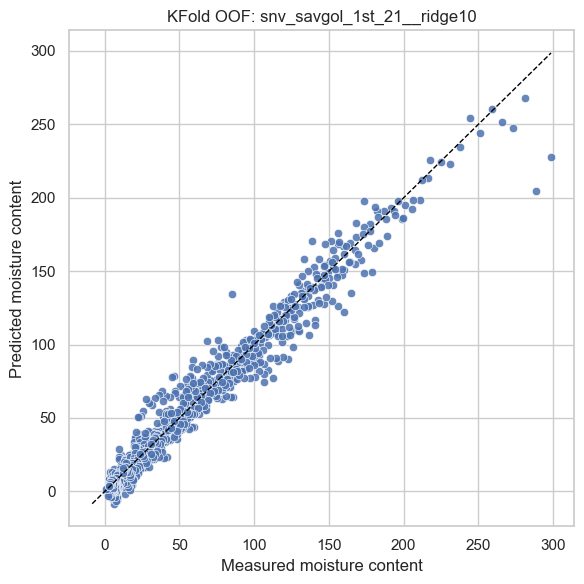

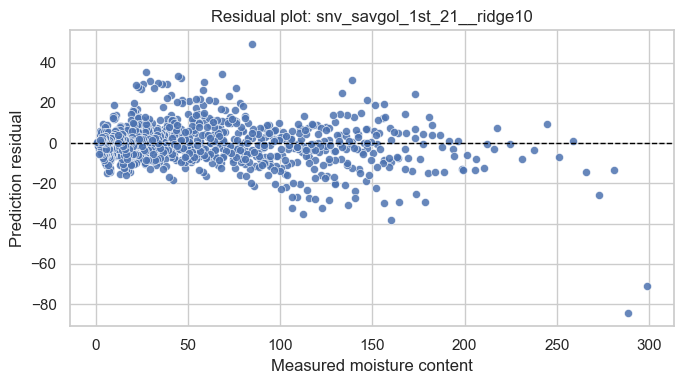

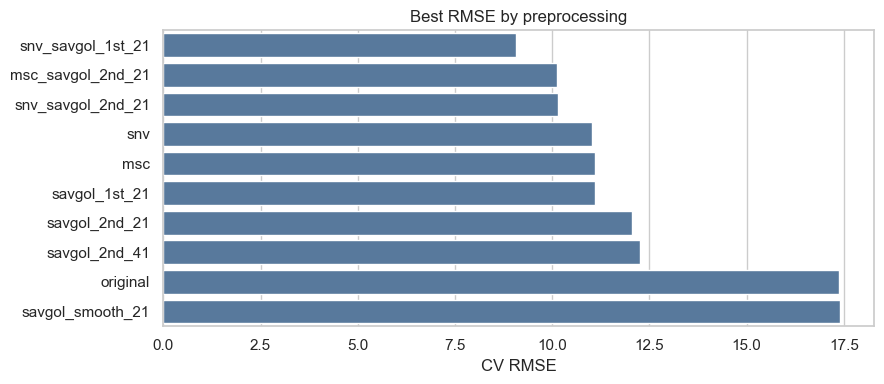

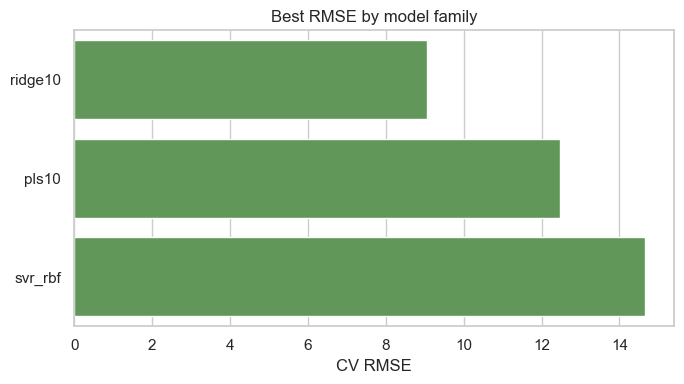

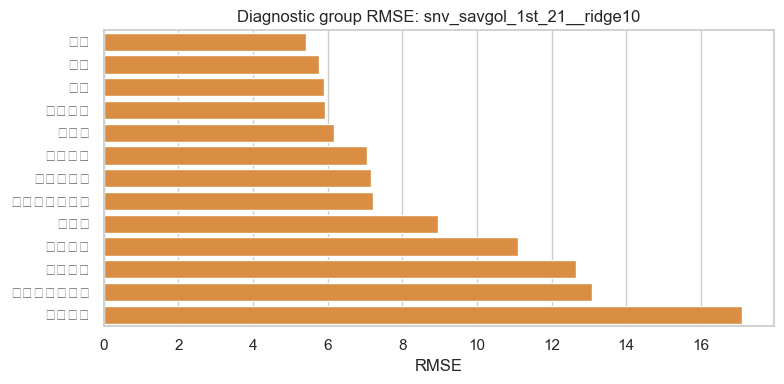

,model_name,diagnostic_group,n,rmse,mae,y_mean
7,snv_savgol_1st_21__ridge10,ナラ,107,5.419371,4.334433,41.790332
6,snv_savgol_1st_21__ridge10,トチ,183,5.763366,4.498672,31.619374
3,snv_savgol_1st_21__ridge10,クリ,91,5.911864,4.348520,73.165228
10,snv_savgol_1st_21__ridge10,ベイマツ,93,5.921927,3.860341,41.831939
8,snv_savgol_1st_21__ridge10,ヒノキ,141,6.167719,4.689186,39.609585
1,snv_savgol_1st_21__ridge10,ウエンジ,87,7.052565,4.794893,15.461847
4,snv_savgol_1st_21__ridge10,スプルース,97,7.162054,5.713867,37.074417
2,snv_savgol_1st_21__ridge10,ウォールナット,110,7.208919,5.532590,57.219697
12,snv_savgol_1st_21__ridge10,米ヒバ,68,8.961796,6.660700,70.095821
0,snv_savgol_1st_21__ridge10,イチョウ,94,11.099672,8.554306,77.991306


,model_name,target_range,n,rmse,mae
0,snv_savgol_1st_21__ridge10,"(0.839, 16.114]",331,4.933885,3.757875
1,snv_savgol_1st_21__ridge10,"(16.114, 29.053]",330,6.681940,4.745773
2,snv_savgol_1st_21__ridge10,"(29.053, 70.264]",330,9.144672,6.469879
3,snv_savgol_1st_21__ridge10,"(70.264, 298.582]",331,13.271256,9.285050


In [7]:
def split_model_name(name: str):
    if "__" in name:
        prep, model = name.split("__", 1)
    else:
        prep, model = "unknown", name
    return prep, model


if RUN_STAGE_A:
    scores_plot = scores_df.copy()
    scores_plot[["preprocessing", "model"]] = scores_plot["model_name"].apply(lambda s: pd.Series(split_model_name(s)))
    best_model_name = scores_df.loc[0, "model_name"]
    best_oof = oof_df[oof_df["model_name"] == best_model_name].dropna(subset=["oof_pred"]).copy()

    fig, ax = plt.subplots(figsize=(6, 6))
    sns.scatterplot(data=best_oof, x="y_true", y="oof_pred", hue=None, ax=ax, s=36, alpha=0.85)
    low = min(best_oof["y_true"].min(), best_oof["oof_pred"].min())
    high = max(best_oof["y_true"].max(), best_oof["oof_pred"].max())
    ax.plot([low, high], [low, high], color="black", linestyle="--", linewidth=1)
    ax.set_title(f"KFold OOF: {best_model_name}")
    ax.set_xlabel("Measured moisture content")
    ax.set_ylabel("Predicted moisture content")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "cv_pred_vs_true.png", dpi=200)
    plt.show()

    best_oof["residual"] = best_oof["oof_pred"] - best_oof["y_true"]
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.scatterplot(data=best_oof, x="y_true", y="residual", hue=None, ax=ax, s=34, alpha=0.85)
    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(f"Residual plot: {best_model_name}")
    ax.set_xlabel("Measured moisture content")
    ax.set_ylabel("Prediction residual")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "residual_plot.png", dpi=200)
    plt.show()

    fig, ax = plt.subplots(figsize=(9, 4))
    prep_summary = scores_plot.groupby("preprocessing", as_index=False)["rmse_mean"].min().sort_values("rmse_mean")
    sns.barplot(data=prep_summary, x="rmse_mean", y="preprocessing", ax=ax, color="#4c78a8")
    ax.set_title("Best RMSE by preprocessing")
    ax.set_xlabel("CV RMSE")
    ax.set_ylabel("")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "preprocessing_comparison.png", dpi=200)
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4))
    model_summary = scores_plot.groupby("model", as_index=False)["rmse_mean"].min().sort_values("rmse_mean")
    sns.barplot(data=model_summary, x="rmse_mean", y="model", ax=ax, color="#59a14f")
    ax.set_title("Best RMSE by model family")
    ax.set_xlabel("CV RMSE")
    ax.set_ylabel("")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "model_comparison.png", dpi=200)
    plt.show()

    diagnostic_group_error_df = summarize_errors_by_diagnostic_group(best_oof)
    range_error_df = summarize_errors_by_target_range(best_oof, bins=4)
    diagnostic_group_error_df.to_csv(OUTPUT_DIR / "diagnostic_group_error_cv.csv", index=False, encoding="utf-8-sig")
    range_error_df.to_csv(OUTPUT_DIR / "target_range_error_cv.csv", index=False, encoding="utf-8-sig")

    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(data=diagnostic_group_error_df.sort_values("rmse"), x="rmse", y="diagnostic_group", ax=ax, color="#f28e2b")
    ax.set_title(f"Diagnostic group RMSE: {best_model_name}")
    ax.set_xlabel("RMSE")
    ax.set_ylabel("")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "diagnostic_group_error.png", dpi=200)
    plt.show()

    display(diagnostic_group_error_df.sort_values("rmse"))
    display(range_error_df)


## 7. CV上位モデルのアンサンブル

OOF予測を横持ち化し、上位3/5/8モデルの単純平均とRMSE逆数重み付き平均を評価します。ここではメタモデル学習をしないため、リークのないOOF予測だけで評価します。


In [8]:
def ensemble_oof_scores(oof_df: pd.DataFrame, scores_df: pd.DataFrame, top_ns=(3, 5, 8)) -> pd.DataFrame:
    base = oof_df.dropna(subset=["oof_pred"]).copy()
    pivot = base.pivot_table(index="sample_id", columns="model_name", values="oof_pred", aggfunc="first")
    meta = base.drop_duplicates("sample_id").set_index("sample_id")[["y_true", "species"]]
    rows = []

    ordered_models = scores_df.sort_values("rmse_mean")["model_name"].tolist()
    rmse_map = scores_df.set_index("model_name")["rmse_mean"].to_dict()

    for n in top_ns:
        selected = [m for m in ordered_models[:n] if m in pivot.columns]
        if not selected:
            continue
        pred_mean = pivot[selected].mean(axis=1)
        mask = pred_mean.notna()
        rows.append({
            "model_name": f"ensemble_top{n}_mean",
            "rmse_mean": rmse_score(meta.loc[mask, "y_true"], pred_mean[mask]),
            "mae_mean": float(mean_absolute_error(meta.loc[mask, "y_true"], pred_mean[mask])),
            "r2_mean": float(r2_score(meta.loc[mask, "y_true"], pred_mean[mask])),
            "n_models": len(selected),
            "members": ";".join(selected),
        })

        weights = np.array([1.0 / max(rmse_map[m], 1e-12) for m in selected], dtype=float)
        weights = weights / weights.sum()
        pred_weighted = pd.Series(np.dot(pivot[selected].values, weights), index=pivot.index)
        mask = pred_weighted.notna()
        rows.append({
            "model_name": f"ensemble_top{n}_weighted_inv_rmse",
            "rmse_mean": rmse_score(meta.loc[mask, "y_true"], pred_weighted[mask]),
            "mae_mean": float(mean_absolute_error(meta.loc[mask, "y_true"], pred_weighted[mask])),
            "r2_mean": float(r2_score(meta.loc[mask, "y_true"], pred_weighted[mask])),
            "n_models": len(selected),
            "members": ";".join(selected),
        })

    return pd.DataFrame(rows).sort_values("rmse_mean").reset_index(drop=True)


if RUN_STAGE_A:
    ensemble_scores_df = ensemble_oof_scores(oof_df, scores_df, top_ns=(3, 5, 8))
    ensemble_scores_df.to_csv(OUTPUT_DIR / "ensemble_scores_cv.csv", index=False, encoding="utf-8-sig")

    combined_scores_df = pd.concat([
        scores_df,
        ensemble_scores_df.assign(n_valid_predictions=len(y), n_failed_folds=0, errors="")
    ], ignore_index=True, sort=False).sort_values("rmse_mean").reset_index(drop=True)
    combined_scores_df.to_csv(OUTPUT_DIR / "model_scores_cv_with_ensembles.csv", index=False, encoding="utf-8-sig")

    display(ensemble_scores_df)
    display(combined_scores_df.head(12))


,model_name,rmse_mean,mae_mean,r2_mean,n_models,members
0,ensemble_top5_weighted_inv_rmse,9.263218,6.115874,0.965015,5,snv_savgol_1st_21__ridge10;msc_savgol_2nd_21__...
1,ensemble_top5_mean,9.306449,6.141066,0.964688,5,snv_savgol_1st_21__ridge10;msc_savgol_2nd_21__...
2,ensemble_top3_weighted_inv_rmse,9.334788,6.302651,0.964472,3,snv_savgol_1st_21__ridge10;msc_savgol_2nd_21__...
3,ensemble_top3_mean,9.376393,6.340944,0.964155,3,snv_savgol_1st_21__ridge10;msc_savgol_2nd_21__...
4,ensemble_top8_weighted_inv_rmse,9.465457,6.371851,0.963471,8,snv_savgol_1st_21__ridge10;msc_savgol_2nd_21__...
5,ensemble_top8_mean,9.537128,6.431603,0.962916,8,snv_savgol_1st_21__ridge10;msc_savgol_2nd_21__...


,model_name,rmse_mean,mae_mean,r2_mean,n_valid_predictions,n_failed_folds,errors,n_models,members
0,snv_savgol_1st_21__ridge10,9.067139,6.065335,0.966481,1322,0,[],NaN,NaN
1,ensemble_top5_weighted_inv_rmse,9.263218,6.115874,0.965015,1322,0,,5.0,snv_savgol_1st_21__ridge10;msc_savgol_2nd_21__...
2,ensemble_top5_mean,9.306449,6.141066,0.964688,1322,0,,5.0,snv_savgol_1st_21__ridge10;msc_savgol_2nd_21__...
3,ensemble_top3_weighted_inv_rmse,9.334788,6.302651,0.964472,1322,0,,3.0,snv_savgol_1st_21__ridge10;msc_savgol_2nd_21__...
4,ensemble_top3_mean,9.376393,6.340944,0.964155,1322,0,,3.0,snv_savgol_1st_21__ridge10;msc_savgol_2nd_21__...
5,ensemble_top8_weighted_inv_rmse,9.465457,6.371851,0.963471,1322,0,,8.0,snv_savgol_1st_21__ridge10;msc_savgol_2nd_21__...
6,ensemble_top8_mean,9.537128,6.431603,0.962916,1322,0,,8.0,snv_savgol_1st_21__ridge10;msc_savgol_2nd_21__...
7,msc_savgol_2nd_21__ridge10,10.117390,7.032438,0.958266,1322,0,[],NaN,NaN
8,snv_savgol_2nd_21__ridge10,10.145176,7.020579,0.958036,1322,0,[],NaN,NaN
9,snv__ridge10,11.026175,7.430156,0.950432,1322,0,[],NaN,NaN


## 8. train全体で再学習し、test予測を保存

CVで上位の単一モデルをtrain全体にfitし、testを予測します。上位モデルの平均、重み付き平均、予測標準偏差も保存します。


In [9]:
def make_prediction_frame(pred, filename_label="prediction") -> pd.DataFrame:
    if SAMPLE_COL is not None and SAMPLE_COL in test.columns:
        out_df = pd.DataFrame({"sample_id": test[SAMPLE_COL].values})
    elif sample_submit is not None and len(sample_submit) == len(test):
        out_df = sample_submit.iloc[:, :1].copy()
        out_df.columns = ["sample_id"]
    else:
        out_df = pd.DataFrame({"sample_id": np.arange(len(test))})
    out_df[filename_label] = np.asarray(pred).ravel()
    return out_df


def fit_predict_candidate(candidate_name: str):
    prep, model_key = candidate_registry[candidate_name]
    estimator = build_pipeline(prep, model_key)
    estimator.fit(X, y)
    pred = np.asarray(estimator.predict(X_test)).ravel()
    return estimator, pred


if RUN_STAGE_A:
    single_model_names = [m for m in scores_df.sort_values("rmse_mean")["model_name"].tolist() if m in candidate_registry]
    top5_names = single_model_names[:5]
    top8_names = single_model_names[:8]

    fitted_models = {}
    test_pred_map = {}
    for name in top8_names:
        print(f"fit full train: {name}")
        est, pred = fit_predict_candidate(name)
        fitted_models[name] = est
        test_pred_map[name] = pred

    best_single_name = top5_names[0]
    best_single_df = make_prediction_frame(test_pred_map[best_single_name], "prediction")
    best_single_df.to_csv(OUTPUT_DIR / "test_predictions_best_single.csv", index=False, encoding="utf-8-sig")

    pls_names = [m for m in single_model_names if m.endswith("__pls10")]
    svr_names = [m for m in single_model_names if m.endswith("__svr_rbf")]
    if pls_names:
        _, pls_pred = fit_predict_candidate(pls_names[0])
        make_prediction_frame(pls_pred, "prediction").to_csv(OUTPUT_DIR / "test_predictions_pls.csv", index=False, encoding="utf-8-sig")
    if svr_names:
        _, svr_pred = fit_predict_candidate(svr_names[0])
        make_prediction_frame(svr_pred, "prediction").to_csv(OUTPUT_DIR / "test_predictions_svr.csv", index=False, encoding="utf-8-sig")

    pred_matrix = np.column_stack([test_pred_map[m] for m in top5_names])
    mean_pred = pred_matrix.mean(axis=1)
    rmse_weights = np.array([1.0 / max(float(scores_df.set_index("model_name").loc[m, "rmse_mean"]), 1e-12) for m in top5_names])
    rmse_weights = rmse_weights / rmse_weights.sum()
    weighted_pred = pred_matrix @ rmse_weights

    ensemble_mean_df = make_prediction_frame(mean_pred, "prediction_mean")
    ensemble_mean_df["prediction_std"] = pred_matrix.std(axis=1)
    ensemble_mean_df["prediction_min"] = pred_matrix.min(axis=1)
    ensemble_mean_df["prediction_max"] = pred_matrix.max(axis=1)
    for j, name in enumerate(top5_names, start=1):
        ensemble_mean_df[f"member_{j}"] = name
    ensemble_mean_df.to_csv(OUTPUT_DIR / "test_predictions_ensemble_mean.csv", index=False, encoding="utf-8-sig")

    ensemble_weighted_df = make_prediction_frame(weighted_pred, "prediction_weighted")
    ensemble_weighted_df["prediction_std"] = pred_matrix.std(axis=1)
    ensemble_weighted_df["prediction_min"] = pred_matrix.min(axis=1)
    ensemble_weighted_df["prediction_max"] = pred_matrix.max(axis=1)
    for j, name in enumerate(top5_names, start=1):
        ensemble_weighted_df[f"member_{j}"] = name
        ensemble_weighted_df[f"weight_{j}"] = rmse_weights[j - 1]
    ensemble_weighted_df.to_csv(OUTPUT_DIR / "test_predictions_ensemble_weighted.csv", index=False, encoding="utf-8-sig")

    print("best single:", best_single_name)
    print("top5 ensemble members:")
    for name, weight in zip(top5_names, rmse_weights):
        print(f"  {name}: weight={weight:.3f}")
    display(ensemble_mean_df.head())


fit full train: snv_savgol_1st_21__ridge10
fit full train: msc_savgol_2nd_21__ridge10
fit full train: snv_savgol_2nd_21__ridge10
fit full train: snv__ridge10
fit full train: msc__ridge10
fit full train: savgol_1st_21__ridge10
fit full train: savgol_2nd_21__ridge10
fit full train: savgol_2nd_41__ridge10
best single: snv_savgol_1st_21__ridge10
top5 ensemble members:
  snv_savgol_1st_21__ridge10: weight=0.226
  msc_savgol_2nd_21__ridge10: weight=0.202
  snv_savgol_2nd_21__ridge10: weight=0.202
  snv__ridge10: weight=0.186
  msc__ridge10: weight=0.185


,sample_id,prediction_mean,prediction_std,prediction_min,prediction_max,member_1,member_2,member_3,member_4,member_5
0,95,172.653120,6.260204,168.445064,185.009056,snv_savgol_1st_21__ridge10,msc_savgol_2nd_21__ridge10,snv_savgol_2nd_21__ridge10,snv__ridge10,msc__ridge10
1,96,159.764396,2.882693,156.429089,163.641524,snv_savgol_1st_21__ridge10,msc_savgol_2nd_21__ridge10,snv_savgol_2nd_21__ridge10,snv__ridge10,msc__ridge10
2,97,155.206606,3.648076,151.572442,159.756125,snv_savgol_1st_21__ridge10,msc_savgol_2nd_21__ridge10,snv_savgol_2nd_21__ridge10,snv__ridge10,msc__ridge10
3,98,146.830576,1.286551,144.838022,148.891273,snv_savgol_1st_21__ridge10,msc_savgol_2nd_21__ridge10,snv_savgol_2nd_21__ridge10,snv__ridge10,msc__ridge10
4,99,136.016278,4.240554,132.257817,144.035387,snv_savgol_1st_21__ridge10,msc_savgol_2nd_21__ridge10,snv_savgol_2nd_21__ridge10,snv__ridge10,msc__ridge10


## 9. Stage B: 軽量な木系・Boosting系・GPRモデル

Stage A上位の前処理だけに絞って、RandomForest、ExtraTrees、GradientBoostingRegressor(GBR)、GaussianProcessRegressor(GPR)を比較する追加枠です。GPRは全波数をそのまま入れると重くなりやすいため、`StandardScaler + PCA(30) + GPR` の軽量構成にしています。必要なときだけ `RUN_STAGE_B = True` にしてください。


In [10]:
def make_stage_b_model(model_key: str):
    """Lightweight Stage B models.

    Keep this intentionally small. Full-grid tree/boosting searches are too slow for routine notebook runs.
    """
    if model_key == "rf":
        return RandomForestRegressor(
            n_estimators=200,
            max_depth=None,
            max_features="sqrt",
            min_samples_leaf=3,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    if model_key == "extratrees":
        return ExtraTreesRegressor(
            n_estimators=200,
            max_depth=None,
            max_features="sqrt",
            min_samples_leaf=3,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
    if model_key == "gbr":
        return GradientBoostingRegressor(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            min_samples_leaf=5,
            random_state=RANDOM_STATE,
        )
    if model_key == "gpr":
        kernel = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e2))
        return Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=30, random_state=RANDOM_STATE)),
            ("model", GaussianProcessRegressor(
                kernel=kernel,
                alpha=1e-6,
                normalize_y=True,
                n_restarts_optimizer=0,
                random_state=RANDOM_STATE,
            )),
        ])
    raise KeyError(model_key)


def build_stage_b_pipeline(preprocessing_name: str, model_key: str):
    model = make_stage_b_model(model_key)
    steps = []
    steps.extend(named_steps_for_preprocessing(preprocessing_name))
    if isinstance(model, Pipeline):
        steps.extend([(f"{model_key}_{name}", step) for name, step in model.steps])
    else:
        steps.append(("model", model))
    return Pipeline(steps)


if RUN_STAGE_B:
    top_preprocessing = (
        scores_df.assign(preprocessing=scores_df["model_name"].str.split("__").str[0])
        .groupby("preprocessing", as_index=False)["rmse_mean"].min()
        .sort_values("rmse_mean")
        .head(2)["preprocessing"]
        .tolist()
    )
    stage_b_model_keys = ["rf", "extratrees", "gbr", "gpr"]
    stage_b_scores, stage_b_oof, stage_b_folds = [], [], []
    total = len(top_preprocessing) * len(stage_b_model_keys)
    run_i = 0
    for prep in top_preprocessing:
        for model_key in stage_b_model_keys:
            run_i += 1
            name = f"{prep}__{model_key}"
            print(f"[{run_i}/{total}] {name}")
            result = evaluate_model_cv(
                estimator=build_stage_b_pipeline(prep, model_key),
                X=X,
                y=y,
                model_name=name,
                cv=cv,
                return_oof=True,
                sample_id=sample_id,
                diagnostic_group=diagnostic_group,
            )
            stage_b_scores.append(result["score"])
            stage_b_oof.append(result["oof_df"])
            stage_b_folds.append(result["fold_scores"])

    stage_b_scores_df = pd.DataFrame(stage_b_scores).sort_values("rmse_mean")
    stage_b_scores_df.to_csv(OUTPUT_DIR / "model_scores_stage_b_cv.csv", index=False, encoding="utf-8-sig")
    pd.concat(stage_b_oof, ignore_index=True).to_csv(OUTPUT_DIR / "oof_predictions_stage_b.csv", index=False, encoding="utf-8-sig")
    pd.concat(stage_b_folds, ignore_index=True).to_csv(OUTPUT_DIR / "fold_scores_stage_b_cv.csv", index=False, encoding="utf-8-sig")
    display(stage_b_scores_df)


[1/8] snv_savgol_1st_21__rf
[2/8] snv_savgol_1st_21__extratrees
[3/8] snv_savgol_1st_21__gbr
[4/8] snv_savgol_1st_21__gpr
[5/8] msc_savgol_2nd_21__rf
[6/8] msc_savgol_2nd_21__extratrees
[7/8] msc_savgol_2nd_21__gbr
[8/8] msc_savgol_2nd_21__gpr


,model_name,rmse_mean,mae_mean,r2_mean,n_valid_predictions,n_failed_folds,errors
3,snv_savgol_1st_21__gpr,2.921313,0.811066,0.996521,1322,0,[]
1,snv_savgol_1st_21__extratrees,5.033072,1.996523,0.989672,1322,0,[]
7,msc_savgol_2nd_21__gpr,5.218144,2.986732,0.988898,1322,0,[]
2,snv_savgol_1st_21__gbr,5.817049,3.374059,0.986204,1322,0,[]
0,snv_savgol_1st_21__rf,6.264671,2.840149,0.983999,1322,0,[]
6,msc_savgol_2nd_21__gbr,6.624932,3.716814,0.982106,1322,0,[]
5,msc_savgol_2nd_21__extratrees,7.186655,3.227286,0.978942,1322,0,[]
4,msc_savgol_2nd_21__rf,8.187390,3.818982,0.972670,1322,0,[]


## 10. ハイパーパラメータ探索の候補

本格探索用のパラメータ候補です。全組み合わせは重いため、Stage A/Bで有望な前処理とモデルに絞って使います。


In [11]:
param_candidates = {
    "pls": {"n_components": [2, 4, 6, 8, 10, 12, 15, 20]},
    "ridge": {"alpha": [0.001, 0.01, 0.1, 1, 10, 100]},
    "elasticnet": {"alpha": [0.001, 0.01, 0.1, 1, 10], "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]},
    "svr": {"C": [0.1, 1, 10, 100], "epsilon": [0.01, 0.05, 0.1, 0.2], "gamma": ["scale", 0.001, 0.01, 0.1], "kernel": ["rbf", "linear"]},
    "rf_extratrees": {"n_estimators": [300, 500], "max_depth": [None, 5, 10, 20], "max_features": ["sqrt", 0.2, 0.5], "min_samples_leaf": [1, 3, 5, 10]},
    "gbr": {"n_estimators": [100, 300, 500], "learning_rate": [0.01, 0.03, 0.05, 0.1], "max_depth": [2, 3, 5], "subsample": [0.6, 0.8, 1.0], "min_samples_leaf": [3, 5, 10]},
}
param_candidates


{'pls': {'n_components': [2, 4, 6, 8, 10, 12, 15, 20]},
 'ridge': {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
 'elasticnet': {'alpha': [0.001, 0.01, 0.1, 1, 10],
  'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
 'svr': {'C': [0.1, 1, 10, 100],
  'epsilon': [0.01, 0.05, 0.1, 0.2],
  'gamma': ['scale', 0.001, 0.01, 0.1],
  'kernel': ['rbf', 'linear']},
 'rf_extratrees': {'n_estimators': [300, 500],
  'max_depth': [None, 5, 10, 20],
  'max_features': ['sqrt', 0.2, 0.5],
  'min_samples_leaf': [1, 3, 5, 10]},
 'gbr': {'n_estimators': [100, 300, 500],
  'learning_rate': [0.01, 0.03, 0.05, 0.1],
  'max_depth': [2, 3, 5],
  'subsample': [0.6, 0.8, 1.0],
  'min_samples_leaf': [3, 5, 10]}}

## 11. 波数範囲別モデル

iPLS-likeに波数範囲を分割し、区間ごとのPLS/Ridge/SVR/GBRを評価する枠です。区間ごとの誤差傾向は、後段のアンサンブル候補として使えます。


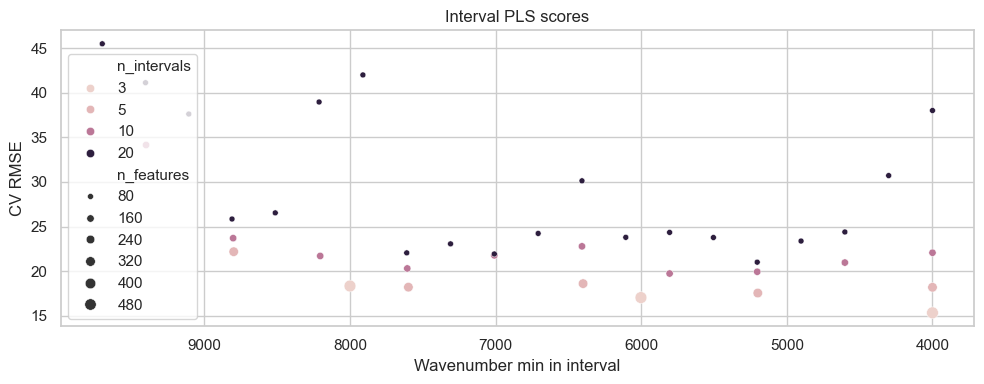

,model_name,rmse_mean,mae_mean,r2_mean,n_valid_predictions,n_failed_folds,errors,n_intervals,interval_id,wn_min,wn_max,n_features
1,interval3_1_4000_5998__ridge10,12.685938,8.746095,0.934385,1322,0,[],3,1,3999.82139,5997.80353,519
29,interval10_2_4602_5199__svr_rbf,15.029903,5.943996,0.907898,1322,0,[],10,2,4601.53030,5199.38209,156
4,interval3_2_6002_7996__ridge10,15.066453,10.717319,0.907450,1322,0,[],3,2,6001.66064,7995.78567,518
0,interval3_1_4000_5998__pls10,15.318772,10.399522,0.904324,1322,0,[],3,1,3999.82139,5997.80353,519
11,interval5_1_4000_5196__svr_rbf,15.478417,5.855444,0.902319,1322,0,[],5,1,3999.82139,5195.52499,311
13,interval5_2_5199_6395__ridge10,15.958951,10.907467,0.896160,1322,0,[],5,2,5199.38209,6395.08569,311
2,interval3_1_4000_5998__svr_rbf,16.182388,5.727177,0.893232,1322,0,[],3,1,3999.82139,5997.80353,519
62,interval20_3_4602_4899__svr_rbf,16.567166,8.117289,0.888094,1322,0,[],20,3,4601.53030,4898.52764,78
65,interval20_4_4902_5199__svr_rbf,16.809123,7.961721,0.884802,1322,0,[],20,4,4902.38475,5199.38209,78
14,interval5_2_5199_6395__svr_rbf,16.882954,5.972234,0.883788,1322,0,[],5,2,5199.38209,6395.08569,311


In [12]:
def make_wavenumber_intervals(wavenumbers: np.ndarray, n_intervals: int) -> list[np.ndarray]:
    order = np.argsort(wavenumbers)
    chunks = np.array_split(order, n_intervals)
    return [np.sort(chunk) for chunk in chunks if len(chunk) > 0]


class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = columns

    def fit(self, X, y=None):
        self.columns_ = np.asarray(self.columns, dtype=int)
        return self

    def transform(self, X):
        X = check_array(X, dtype=float)
        return X[:, self.columns_]


if RUN_INTERVAL_SELECTION:
    interval_rows = []
    for n_intervals in [3, 5, 10, 20]:
        for interval_id, cols in enumerate(make_wavenumber_intervals(wavenumbers, n_intervals), start=1):
            wn_min, wn_max = wavenumbers[cols].min(), wavenumbers[cols].max()
            for model_key in ["pls10", "ridge10", "svr_rbf"]:
                name = f"interval{n_intervals}_{interval_id}_{wn_min:.0f}_{wn_max:.0f}__{model_key}"
                estimator = Pipeline([
                    ("select", ColumnSelector(cols)),
                    ("savgol", SavitzkyGolayTransformer(window_length=21, polyorder=2, deriv=2)),
                    ("model", make_stage_a_model(model_key)),
                ])
                result = evaluate_model_cv(
                    estimator=estimator,
                    X=X.values,
                    y=y,
                    model_name=name,
                    cv=cv,
                    sample_id=sample_id,
                    diagnostic_group=diagnostic_group,
                )
                row = result["score"] | {"n_intervals": n_intervals, "interval_id": interval_id, "wn_min": wn_min, "wn_max": wn_max, "n_features": len(cols)}
                interval_rows.append(row)

    interval_scores_df = pd.DataFrame(interval_rows).sort_values("rmse_mean")
    interval_scores_df.to_csv(OUTPUT_DIR / "interval_model_scores_cv.csv", index=False, encoding="utf-8-sig")

    fig, ax = plt.subplots(figsize=(10, 4))
    plot_df = interval_scores_df[interval_scores_df["model_name"].str.endswith("__pls10")].copy()
    sns.scatterplot(data=plot_df, x="wn_min", y="rmse_mean", hue="n_intervals", size="n_features", ax=ax)
    ax.invert_xaxis()
    ax.set_title("Interval PLS scores")
    ax.set_xlabel("Wavenumber min in interval")
    ax.set_ylabel("CV RMSE")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "interval_pls_scores.png", dpi=200)
    plt.show()
    display(interval_scores_df.head(20))


## 12. VIP scoreと波数選択

PLSのVIP score、相関上位波数、SelectKBestをPipeline内でfitするための部品です。特徴量選択は必ずCV内でfitします。


In [13]:
def calculate_vip(pls: PLSRegression) -> np.ndarray:
    t = pls.x_scores_
    w = pls.x_weights_
    q = pls.y_loadings_.reshape(-1, 1)
    p, h = w.shape
    s = np.diag(t.T @ t @ q @ q.T).reshape(h, -1)
    total_s = np.sum(s)
    if total_s <= 0:
        return np.ones(p)
    vip = np.sqrt(p * (w ** 2 @ s).ravel() / total_s)
    return vip


class VIPSelector(BaseEstimator, TransformerMixin):
    def __init__(self, n_components: int = 10, threshold: float | None = 1.0, top_k: int | None = None):
        self.n_components = n_components
        self.threshold = threshold
        self.top_k = top_k

    def fit(self, X, y):
        X = check_array(X, dtype=float)
        n_components = max(1, min(int(self.n_components), X.shape[0] - 1, X.shape[1]))
        self.pls_ = PLSRegression(n_components=n_components, scale=True)
        self.pls_.fit(X, y)
        self.vip_scores_ = calculate_vip(self.pls_)
        if self.top_k is not None:
            k = min(int(self.top_k), X.shape[1])
            selected = np.argsort(self.vip_scores_)[-k:]
            self.support_ = np.zeros(X.shape[1], dtype=bool)
            self.support_[selected] = True
        else:
            self.support_ = self.vip_scores_ >= float(self.threshold)
            if not self.support_.any():
                self.support_[np.argmax(self.vip_scores_)] = True
        return self

    def transform(self, X):
        check_is_fitted(self, "support_")
        X = check_array(X, dtype=float)
        return X[:, self.support_]


if RUN_VIP_SELECTION:
    vip_candidates = {
        "vip_gt_1": VIPSelector(n_components=10, threshold=1.0),
        "vip_gt_0_8": VIPSelector(n_components=10, threshold=0.8),
        "vip_top100": VIPSelector(n_components=10, top_k=100),
        "vip_top200": VIPSelector(n_components=10, top_k=200),
        "corr_top50": SelectKBest(score_func=f_regression, k=50),
        "corr_top100": SelectKBest(score_func=f_regression, k=100),
        "corr_top200": SelectKBest(score_func=f_regression, k=200),
    }
    vip_rows = []
    for selector_name, selector in vip_candidates.items():
        estimator = Pipeline([
            ("snv", SNVTransformer()),
            ("savgol", SavitzkyGolayTransformer(window_length=21, polyorder=2, deriv=2)),
            ("selector", selector),
            ("model", AdaptivePLSRegression(n_components=10, scale=True)),
        ])
        result = evaluate_model_cv(
            estimator=estimator,
            X=X,
            y=y,
            model_name=f"snv_savgol_2nd_21__{selector_name}__pls10",
            cv=cv,
            sample_id=sample_id,
            diagnostic_group=diagnostic_group,
        )
        vip_rows.append(result["score"])

    vip_scores_df = pd.DataFrame(vip_rows).sort_values("rmse_mean")
    vip_scores_df.to_csv(OUTPUT_DIR / "vip_feature_selection_scores_cv.csv", index=False, encoding="utf-8-sig")
    display(vip_scores_df)


## 13. Adversarial validation

train/testを分類し、分布差が強いかを確認します。AUCが高い場合、testらしいtrainサンプルへの重み付けや、分布差の大きい波数の確認を検討します。


In [14]:
if RUN_ADVERSARIAL_VALIDATION:
    X_adv = pd.concat([X, X_test], ignore_index=True)
    y_adv = np.r_[np.zeros(len(X), dtype=int), np.ones(len(X_test), dtype=int)]
    cv_adv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    adv_lr = Pipeline([
        ("snv", SNVTransformer()),
        ("savgol", SavitzkyGolayTransformer(window_length=21, polyorder=2, deriv=2)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)),
    ])
    adv_rf = Pipeline([
        ("snv", SNVTransformer()),
        ("savgol", SavitzkyGolayTransformer(window_length=21, polyorder=2, deriv=2)),
        ("model", RandomForestClassifier(n_estimators=500, max_features="sqrt", random_state=RANDOM_STATE, n_jobs=-1)),
    ])

    adv_lr_pred = cross_val_predict(adv_lr, X_adv, y_adv, cv=cv_adv, method="predict_proba")[:, 1]
    adv_rf_pred = cross_val_predict(adv_rf, X_adv, y_adv, cv=cv_adv, method="predict_proba")[:, 1]
    adv_summary = pd.DataFrame({
        "model": ["logistic_regression", "random_forest"],
        "auc": [roc_auc_score(y_adv, adv_lr_pred), roc_auc_score(y_adv, adv_rf_pred)],
    })
    display(adv_summary)

    adv_rf.fit(X_adv, y_adv)
    rf_model = adv_rf.named_steps["model"]
    importance = pd.DataFrame({"wavenumber": wavenumbers, "importance": rf_model.feature_importances_}).sort_values("importance", ascending=False)
    importance.to_csv(OUTPUT_DIR / "adversarial_validation_importance.csv", index=False, encoding="utf-8-sig")

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.lineplot(data=importance.sort_values("wavenumber"), x="wavenumber", y="importance", ax=ax)
    ax.invert_xaxis()
    ax.set_title("Adversarial validation importance")
    ax.set_xlabel("Wavenumber cm^-1")
    ax.set_ylabel("Importance")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "adversarial_validation_importance.png", dpi=200)
    plt.show()

    train_test_likeness = pd.DataFrame({
        "sample_id": sample_id,
        "species": species,
        "test_likeness_lr": adv_lr_pred[:len(X)],
        "test_likeness_rf": adv_rf_pred[:len(X)],
    })
    train_test_likeness.to_csv(OUTPUT_DIR / "train_test_likeness.csv", index=False, encoding="utf-8-sig")


## 14. Local model

PCA空間でtestに近いtrainサンプルだけを使い、サンプルごとにPLS/RidgeをfitするLocal modelの枠です。まずはtest予測候補として使います。


In [15]:
def predict_local_pls(X_train, y_train, X_query, k=100, n_components=10, preprocessing=None, random_state=RANDOM_STATE):
    if preprocessing is None:
        preprocessing = Pipeline([
            ("snv", SNVTransformer()),
            ("savgol", SavitzkyGolayTransformer(window_length=21, polyorder=2, deriv=2)),
            ("scaler", StandardScaler()),
        ])
    X_train_proc = preprocessing.fit_transform(X_train, y_train)
    X_query_proc = preprocessing.transform(X_query)

    pca_components = min(20, X_train_proc.shape[0] - 1, X_train_proc.shape[1])
    pca = PCA(n_components=pca_components, random_state=random_state)
    train_scores = pca.fit_transform(X_train_proc)
    query_scores = pca.transform(X_query_proc)

    preds = []
    for row in query_scores:
        distances = np.sqrt(((train_scores - row) ** 2).sum(axis=1))
        idx = np.argsort(distances)[: min(k, len(y_train))]
        model = AdaptivePLSRegression(n_components=n_components, scale=True)
        model.fit(X_train_proc[idx], np.asarray(y_train)[idx])
        preds.append(float(model.predict(X_query_proc[[len(preds)]])[0]))
    return np.array(preds)


if RUN_LOCAL_MODEL:
    local_pred_map = {}
    for k in [50, 100, 200, 300]:
        print(f"Local PLS k={k}")
        local_pred_map[k] = predict_local_pls(X.values, y.values, X_test.values, k=k, n_components=10)
        make_prediction_frame(local_pred_map[k], "prediction").to_csv(OUTPUT_DIR / f"test_predictions_local_pls_k{k}.csv", index=False, encoding="utf-8-sig")


## 15. Stacking

Stackingでは、必ずOOF予測をメタモデルの入力にします。ここではRidge / ElasticNet stackingのOOF評価と、test予測保存の枠を用意します。


In [16]:
if RUN_STACKING:
    base = oof_df.dropna(subset=["oof_pred"]).copy()
    top_models = scores_df.sort_values("rmse_mean").head(8)["model_name"].tolist()
    pivot = base.pivot_table(index="sample_id", columns="model_name", values="oof_pred", aggfunc="first")
    meta = base.drop_duplicates("sample_id").set_index("sample_id")[["y_true"]]
    stack_X = pivot[top_models].dropna()
    stack_y = meta.loc[stack_X.index, "y_true"]

    stack_models = {
        "ridge_stacking": Ridge(alpha=1.0),
        "elasticnet_stacking": ElasticNet(alpha=0.001, l1_ratio=0.3, max_iter=20000, random_state=RANDOM_STATE),
    }
    stack_rows = []
    for name, stack_model in stack_models.items():
        pred = cross_val_predict(stack_model, stack_X, stack_y, cv=make_sample_cv(N_SPLITS_MAX))
        stack_rows.append({
            "model_name": name,
            "rmse_mean": rmse_score(stack_y, pred),
            "mae_mean": float(mean_absolute_error(stack_y, pred)),
            "r2_mean": float(r2_score(stack_y, pred)),
            "members": ";".join(top_models),
        })
    stack_scores_df = pd.DataFrame(stack_rows).sort_values("rmse_mean")
    stack_scores_df.to_csv(OUTPUT_DIR / "stacking_scores_cv.csv", index=False, encoding="utf-8-sig")
    display(stack_scores_df)

    if "test_pred_map" not in globals() or not all(m in test_pred_map for m in top_models):
        test_pred_map = {}
        for name in top_models:
            _, pred = fit_predict_candidate(name)
            test_pred_map[name] = pred
    stack_test_X = pd.DataFrame({m: test_pred_map[m] for m in top_models})
    best_stack_name = stack_scores_df.iloc[0]["model_name"]
    final_stack_model = clone(stack_models[best_stack_name])
    final_stack_model.fit(stack_X, stack_y)
    stack_test_pred = final_stack_model.predict(stack_test_X[top_models])
    make_prediction_frame(stack_test_pred, "prediction").to_csv(OUTPUT_DIR / "test_predictions_stacking.csv", index=False, encoding="utf-8-sig")


## 16. 図示用: train/test 推定含水率と実測含水率

trainのOOF予測とtest予測を同じ図示用データにまとめます。testに実測含水率がない場合は、左側にtrainの実測 vs 推定、右側にtrain/testの推定分布を表示します。将来testに実測列が追加された場合は、testも散布図とR2/MAE/RMSE計算に自動で含まれます。


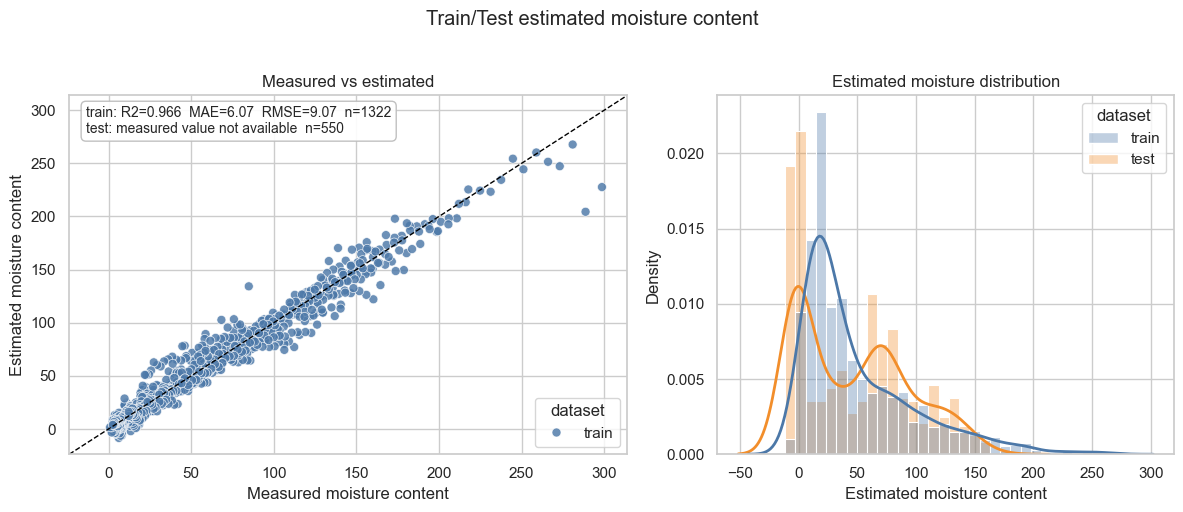

,dataset,source,n,measured_n,pred_mean,pred_std
0,test,test_predictions_ensemble_weighted.csv,550,0,46.606112,47.080351
1,train,snv_savgol_1st_21__ridge10,1322,1322,49.842997,48.448068


In [17]:

def _resolve_prediction_column(df: pd.DataFrame, preferred: str | None = None) -> str:
    if preferred is not None and preferred in df.columns:
        return preferred
    candidates = [
        "prediction_weighted",
        "prediction_mean",
        "prediction",
        "oof_pred",
        "estimated_moisture",
        "predicted_moisture",
    ]
    for col in candidates:
        if col in df.columns:
            return col
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if not numeric_cols:
        raise ValueError("No numeric prediction column was found.")
    return numeric_cols[-1]


def _default_test_prediction_file() -> Path | None:
    candidates = [
        OUTPUT_DIR / "test_predictions_ensemble_weighted.csv",
        OUTPUT_DIR / "test_predictions_ensemble_mean.csv",
        OUTPUT_DIR / "test_predictions_best_single.csv",
        OUTPUT_DIR / "test_predictions_pls.csv",
        OUTPUT_DIR / "test_predictions_svr.csv",
    ]
    for path in candidates:
        if path.exists():
            return path
    return None


def _metrics_text(plot_df: pd.DataFrame) -> str:
    lines = []
    for dataset, part in plot_df.dropna(subset=["measured", "predicted"]).groupby("dataset", sort=False):
        if len(part) < 2:
            continue
        r2 = r2_score(part["measured"], part["predicted"])
        mae = mean_absolute_error(part["measured"], part["predicted"])
        rmse = rmse_score(part["measured"], part["predicted"])
        lines.append(f"{dataset}: R2={r2:.3f}  MAE={mae:.2f}  RMSE={rmse:.2f}  n={len(part)}")
    no_measured = plot_df[plot_df["measured"].isna()]["dataset"].dropna().unique().tolist()
    for dataset in no_measured:
        n = int((plot_df["dataset"] == dataset).sum())
        lines.append(f"{dataset}: measured value not available  n={n}")
    return "\n".join(lines) if lines else "No measured values available."


def make_train_test_prediction_plot_data(
    selected_model_name: str | None = None,
    test_prediction_file: Path | None = None,
    test_prediction_col: str | None = None,
) -> pd.DataFrame:
    """Build one tidy dataframe for plotting train/test predictions.

    train uses KFold OOF predictions from ``oof_df``. test uses the saved prediction CSV.
    If test has a measured target column, it is included; otherwise metrics are computed for train only.
    """
    if "oof_df" not in globals() or "scores_df" not in globals():
        required = [OUTPUT_DIR / "oof_predictions.csv", OUTPUT_DIR / "model_scores_cv.csv"]
        missing = [p for p in required if not p.exists()]
        if missing:
            raise FileNotFoundError(f"Run Stage A first or provide saved outputs. Missing: {missing}")
        local_oof_df = pd.read_csv(OUTPUT_DIR / "oof_predictions.csv")
        local_scores_df = pd.read_csv(OUTPUT_DIR / "model_scores_cv.csv")
    else:
        local_oof_df = oof_df.copy()
        local_scores_df = scores_df.copy()

    if selected_model_name is None:
        selected_model_name = local_scores_df.sort_values("rmse_mean").iloc[0]["model_name"]

    train_plot = local_oof_df[local_oof_df["model_name"] == selected_model_name].dropna(subset=["oof_pred"]).copy()
    train_plot = train_plot.rename(columns={"y_true": "measured", "oof_pred": "predicted"})
    train_plot["dataset"] = "train"
    train_plot["source"] = selected_model_name
    keep_cols = ["sample_id", "dataset", "diagnostic_group", "measured", "predicted", "source"]
    plot_parts = [train_plot[keep_cols]]

    test_prediction_file = test_prediction_file or _default_test_prediction_file()
    if test_prediction_file is not None and Path(test_prediction_file).exists():
        test_pred_df = pd.read_csv(test_prediction_file)
        pred_col = _resolve_prediction_column(test_pred_df, test_prediction_col)

        if "sample_id" in test_pred_df.columns:
            test_sample_id = test_pred_df["sample_id"].values
        elif SAMPLE_COL is not None and SAMPLE_COL in test.columns:
            test_sample_id = test[SAMPLE_COL].values
        else:
            test_sample_id = np.arange(len(test_pred_df))

        if SPECIES_COL is not None and SPECIES_COL in test.columns:
            test_diagnostic_group = test[SPECIES_COL].astype(str).values
        elif SPECIES_NUM_COL is not None and SPECIES_NUM_COL in test.columns:
            test_diagnostic_group = test[SPECIES_NUM_COL].astype(str).values
        else:
            test_diagnostic_group = np.repeat("test", len(test_pred_df))

        measured = test[TARGET_COL].astype(float).values if TARGET_COL in test.columns else np.repeat(np.nan, len(test_pred_df))
        test_plot = pd.DataFrame({
            "sample_id": test_sample_id,
            "dataset": "test",
            "diagnostic_group": test_diagnostic_group,
            "measured": measured,
            "predicted": test_pred_df[pred_col].astype(float).values,
            "source": Path(test_prediction_file).name,
        })
        plot_parts.append(test_plot[keep_cols])
    else:
        print("No test prediction CSV was found. Plotting train OOF only.")

    return pd.concat(plot_parts, ignore_index=True)


def plot_train_test_predicted_vs_measured(
    plot_df: pd.DataFrame,
    title: str = "Estimated vs measured moisture content",
    save_path: Path | None = None,
):
    """Plot measured vs estimated moisture and display R2/MAE/RMSE inside the figure."""
    with_measured = plot_df.dropna(subset=["measured", "predicted"]).copy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1.1, 0.9]})
    ax_scatter, ax_dist = axes

    palette = {"train": "#4c78a8", "test": "#f28e2b"}
    if not with_measured.empty:
        sns.scatterplot(
            data=with_measured,
            x="measured",
            y="predicted",
            hue="dataset",
            style="dataset",
            palette=palette,
            s=42,
            alpha=0.82,
            ax=ax_scatter,
        )
        low = min(with_measured["measured"].min(), with_measured["predicted"].min())
        high = max(with_measured["measured"].max(), with_measured["predicted"].max())
        pad = (high - low) * 0.05 if high > low else 1.0
        ax_scatter.plot([low - pad, high + pad], [low - pad, high + pad], color="black", linestyle="--", linewidth=1)
        ax_scatter.set_xlim(low - pad, high + pad)
        ax_scatter.set_ylim(low - pad, high + pad)
    else:
        ax_scatter.text(0.5, 0.5, "No measured values", ha="center", va="center", transform=ax_scatter.transAxes)

    ax_scatter.set_title("Measured vs estimated")
    ax_scatter.set_xlabel("Measured moisture content")
    ax_scatter.set_ylabel("Estimated moisture content")
    ax_scatter.text(
        0.03,
        0.97,
        _metrics_text(plot_df),
        transform=ax_scatter.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#bbbbbb", "alpha": 0.92},
    )

    sns.histplot(
        data=plot_df.dropna(subset=["predicted"]),
        x="predicted",
        hue="dataset",
        palette=palette,
        bins=32,
        stat="density",
        common_norm=False,
        alpha=0.35,
        ax=ax_dist,
    )
    sns.kdeplot(
        data=plot_df.dropna(subset=["predicted"]),
        x="predicted",
        hue="dataset",
        palette=palette,
        common_norm=False,
        linewidth=2,
        ax=ax_dist,
        legend=False,
    )
    ax_dist.set_title("Estimated moisture distribution")
    ax_dist.set_xlabel("Estimated moisture content")
    ax_dist.set_ylabel("Density")

    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    if save_path is not None:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()
    return fig, axes


PLOT_MODEL_NAME = None  # NoneならCV RMSE最良の単一モデルを使う
PLOT_TEST_PREDICTION_FILE = None  # Noneならensemble_weighted -> ensemble_mean -> best_singleの順で探す

try:
    train_test_plot_df = make_train_test_prediction_plot_data(
        selected_model_name=PLOT_MODEL_NAME,
        test_prediction_file=PLOT_TEST_PREDICTION_FILE,
    )
    train_test_plot_df.to_csv(OUTPUT_DIR / "train_test_prediction_plot_data.csv", index=False, encoding="utf-8-sig")
    plot_train_test_predicted_vs_measured(
        train_test_plot_df,
        title="Train/Test estimated moisture content",
        save_path=FIGURE_DIR / "train_test_predicted_vs_measured.png",
    )
    display(train_test_plot_df.groupby(["dataset", "source"], dropna=False).agg(n=("predicted", "size"), measured_n=("measured", lambda s: int(s.notna().sum())), pred_mean=("predicted", "mean"), pred_std=("predicted", "std")).reset_index())
except FileNotFoundError as exc:
    print(exc)
    print("Stage Aを実行して予測CSVを作成したあと、このセルを再実行してください。")


## 17. 完了チェック

主要ファイルの存在を確認します。Stage A実行後に、下の一覧が揃っていれば最小構成は完了です。


In [18]:
expected_outputs = [
    OUTPUT_DIR / "model_scores_cv.csv",
    OUTPUT_DIR / "fold_scores_cv.csv",
    OUTPUT_DIR / "oof_predictions.csv",
    OUTPUT_DIR / "ensemble_scores_cv.csv",
    OUTPUT_DIR / "test_predictions_best_single.csv",
    OUTPUT_DIR / "test_predictions_pls.csv",
    OUTPUT_DIR / "test_predictions_svr.csv",
    OUTPUT_DIR / "test_predictions_ensemble_mean.csv",
    OUTPUT_DIR / "test_predictions_ensemble_weighted.csv",
    FIGURE_DIR / "cv_pred_vs_true.png",
    FIGURE_DIR / "residual_plot.png",
    FIGURE_DIR / "preprocessing_comparison.png",
    FIGURE_DIR / "diagnostic_group_error.png",
    FIGURE_DIR / "train_test_predicted_vs_measured.png",
    OUTPUT_DIR / "train_test_prediction_plot_data.csv",
]

status = pd.DataFrame({
    "path": [str(p.relative_to(PROJECT_DIR)) for p in expected_outputs],
    "exists": [p.exists() for p in expected_outputs],
})
display(status)


,path,exists
0,outputs/model_scores_cv.csv,True
1,outputs/fold_scores_cv.csv,True
2,outputs/oof_predictions.csv,True
3,outputs/ensemble_scores_cv.csv,True
4,outputs/test_predictions_best_single.csv,True
5,outputs/test_predictions_pls.csv,True
6,outputs/test_predictions_svr.csv,True
7,outputs/test_predictions_ensemble_mean.csv,True
8,outputs/test_predictions_ensemble_weighted.csv,True
9,outputs/figures/cv_pred_vs_true.png,True
